In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:

# 1. Generate a synthetic dataset (Replace with your actual pandas DataFrame)
# Creates a dataset with 1000 samples, 10 features, where 4 features actually affect the target
X, y = make_regression(n_samples=1000, n_features=10, n_informative=4, noise=15.0, random_state=42)
feature_names = [f"Feature_{i}" for i in range(1, 11)]
df_X = pd.DataFrame(X, columns=feature_names)




In [8]:
df_X

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10
0,0.900399,1.278866,-0.952316,0.451225,-0.772659,0.830192,-0.676995,0.185176,0.425445,0.222290
1,-1.765388,-0.622270,-1.840266,1.740941,-0.504298,-0.607824,1.328166,-0.215787,-1.177761,1.469784
2,-1.129850,0.466431,0.520689,-0.823837,0.997059,1.127350,-1.079533,0.473145,-0.702911,-0.237807
3,-2.059160,0.269306,1.149487,0.798501,0.407690,0.581000,-1.574342,1.466442,-1.409216,-1.532598
4,-0.200685,-0.249656,0.207542,-0.404696,1.847867,1.190530,-1.346786,-2.391079,-1.019801,0.979260
...,...,...,...,...,...,...,...,...,...,...
995,0.490975,-0.583077,-0.167122,0.734878,-0.248691,1.607346,0.282580,0.307407,0.815737,0.860473
996,-0.571179,-0.681984,-1.001620,0.572583,1.797687,0.640843,-0.281100,0.208383,-2.041735,-0.247177
997,0.590655,1.044161,0.681891,1.108704,0.583928,-0.359292,1.846707,2.526932,-0.530869,-0.489439
998,-0.825292,-0.850975,0.863924,-0.492918,-0.187727,0.840607,0.769136,-0.902654,2.698329,0.242071


In [3]:

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df_X, y, test_size=0.2, random_state=42)

# 3. Initialize the Random Forest Regressor
# n_jobs=-1 utilizes all available CPU cores for faster local execution
rf_regressor = RandomForestRegressor(
    n_estimators=100,        # Number of trees in the forest
    max_depth=None,          # Expand nodes until all leaves are pure or contain less than min_samples_split
    min_samples_split=2,     # Minimum number of samples required to split an internal node
    random_state=42,         # Ensures reproducibility
    n_jobs=-1                
)

# 4. Train the model
print("Training the model...")
rf_regressor.fit(X_train, y_train)


Training the model...


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [6]:

# 5. Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# 6. Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2*100:.2f} % ")



--- Model Evaluation Metrics ---
Mean Squared Error (MSE): 299.36
Root Mean Squared Error (RMSE): 17.30
Mean Absolute Error (MAE): 13.86
R-squared (R2) Score: 81.49 % 


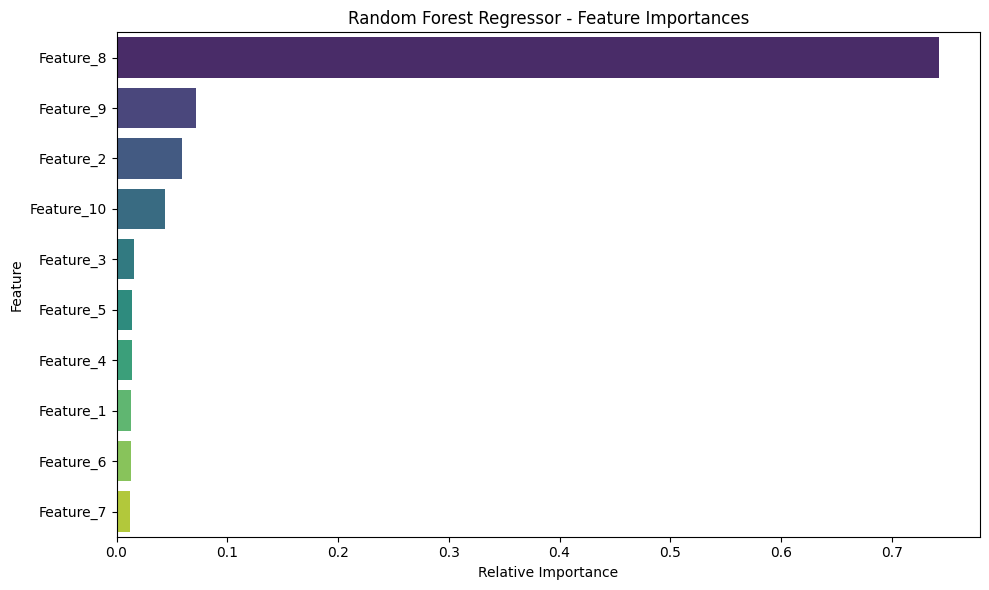

In [7]:

# 7. Visualize Feature Importance
# Random Forests automatically calculate how much each feature contributes to decreasing variance
importances = rf_regressor.feature_importances_

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, hue='Feature', palette='viridis', legend=False)
plt.title('Random Forest Regressor - Feature Importances')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
rf_regressor.predict([[[0.900399], [1.278866], ... , [0.222290]]])

d:\ANN_PTROJECT\penve\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


ValueError: X has 1 features, but RandomForestRegressor is expecting 10 features as input.